# Pathway 1: Single Solid Analysis

This interactive tutorial walks through the simplest analysis pathway: a single rectangular waveguide
solved with the Frequency Domain Solver (FDS) and compared against the analytical solution.

```
EMProject  →  Create Geometry  →  FDS Solve  →  Plot & Compare
```

## Overview

All simulations in `cavsim3d` are managed through the `EMProject` class, which provides:
- Project directory management and persistence
- Geometry creation/import and meshing
- Solver configuration and execution
- Result access and plotting

## 1. Create Project & Geometry

We create a rectangular waveguide with:
- Width $a = 100$ mm
- Length $L = 200$ mm

The `EMProject` class manages the entire simulation lifecycle.

In [4]:
from core.em_project import EMProject
from geometry.primitives import RectangularWaveguide
import matplotlib.pyplot as plt
%matplotlib widget

# 1. Create the project
project_name = 'pathway1_single_rwg'
base_dir = './simulations'  # Change to your preferred simulation directory
proj = EMProject(name=project_name, base_dir=base_dir)

Creating new project 'pathway1_single_rwg' at simulations\pathway1_single_rwg


### Create Geometry

For a single-component analysis, we create a `RectangularWaveguide` primitive
and assign it to the project. The geometry is automatically saved when the project is saved.

In [7]:
# 2. Create rectangular waveguide geometry
#    Uncomment the following lines on first run to create the geometry.
#    On subsequent runs, the project loads automatically.

rwg = RectangularWaveguide(a=0.1, L=0.2)
proj.geometry = rwg
proj.save()

# Access geometry from the loaded project
geo = proj.geo
print(f"Geometry loaded: {type(geo).__name__}")

Saving project to simulations\pathway1_single_rwg
Geometry loaded: RectangularWaveguide


## 2. Visualise the Mesh

The waveguide mesh can be visualised interactively using NGSolve's WebGUI.

In [8]:
geo.show('mesh')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

## 3. Solve the Full-Order Model (FOM)

The solver is configured using a dictionary containing all parameters:

| Parameter | Description |
|-----------|-------------|
| `nportmodes` | Number of modes per port |
| `order` | Polynomial order of the finite element space |
| `nsamples` | Number of frequency sample points |
| `fmin` | Minimum frequency (GHz) |
| `fmax` | Maximum frequency (GHz) |
| `solver_type` | `'direct'` or `'iterative'` |

At each frequency $\omega_i$, the solver computes:

$$
(\mathbf{K} - \omega_i^2 \mathbf{M}) \mathbf{x}_i = \mathbf{B} \mathbf{a}_i
$$

In [9]:
# 3. Configure and run the frequency domain solver
fom_config = {
    'nportmodes': 1,
    'order': 3,
    'nsamples': 100,
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct',
    # 'rerun': True  # Uncomment to force re-solve even if results exist
}

fom_result = proj.fds.solve(config=fom_config)

INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['vacuum']
INFO:: Total Ports (2): ['port1', 'port2']
INFO:: 
Domain-Port Mapping:
  vacuum: ['port1 (external, input)', 'port2 (external, output)']

Assembling Matrices...
Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 1
	------------------------------------------------------------
	  port1: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  port2: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  Precomputing boundary mass matrices (once per port)...
	    Done for 2 port(s)
here is the order of the ports ['port1', 'port2']
USING analytic for port port1
	port1 mode 0: TE_10, kc=31.4159, σ=+1


USING analytic for port port2
	port2 mode 0: TE_10, kc=31.4159, σ=-1


	------------------------------------------------------

## 4. Plot S-Parameters

For a single (non-compound) structure, results are accessed via `proj.fds.fom`.
The `plot_s()` and `plot_z()` methods accept a list of parameter labels in the format
`'port(mode)port(mode)'`, e.g., `'1(1)1(1)'` for $S_{11}$ mode 1.

Text(0.5, 0.98, 'Single RWG — S-Parameters')

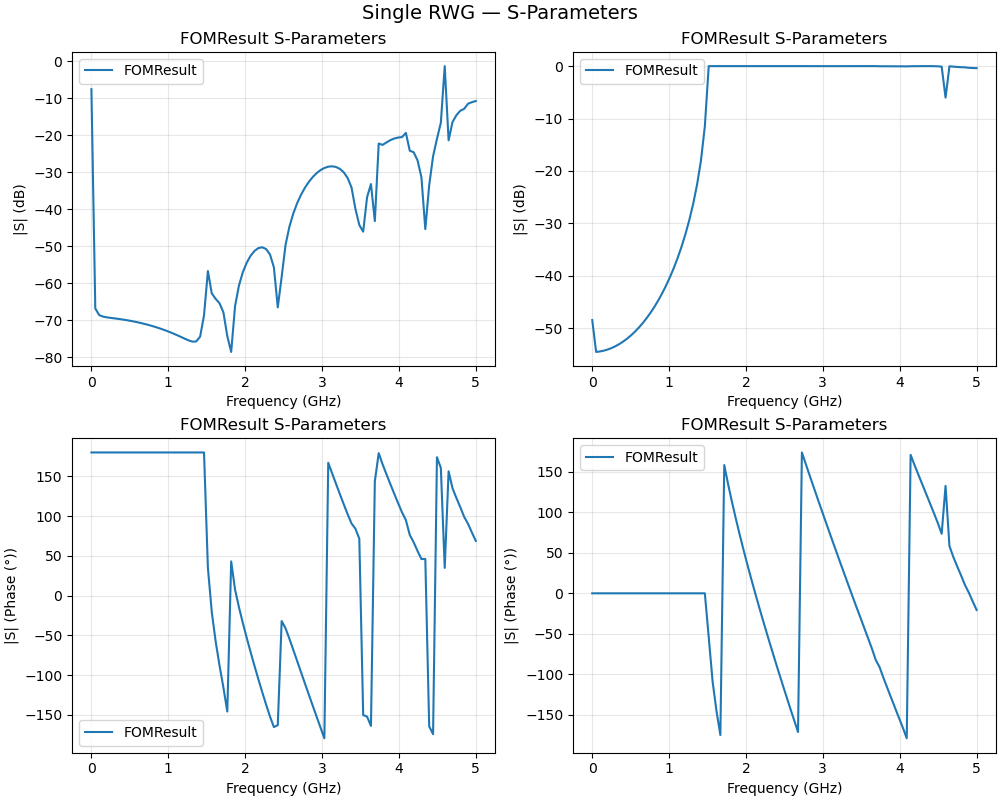

In [10]:
# 4. Plot S-parameters: magnitude and phase
which = [['1(1)1(1)'], ['1(1)2(1)']]

fig, axs = plt.subplot_mosaic(
    [[1, 2], [3, 4]], figsize=(10, 8), layout='constrained'
)

for idx, wh in enumerate(which):
    # Magnitude
    proj.fds.fom.plot_s(wh, ax=axs[idx + 1])
    # Phase
    proj.fds.fom.plot_s(wh, plot_type='phase', ax=axs[idx + 3])

fig.suptitle('Single RWG — S-Parameters', fontsize=14)

## 5. Compare with Analytical Solution

The `RWGAnalytical` class provides closed-form S- and Z-parameters for a
rectangular waveguide, allowing verification of the numerical results.

Text(0.5, 0.98, 'FOM vs Analytical — S-Parameters')

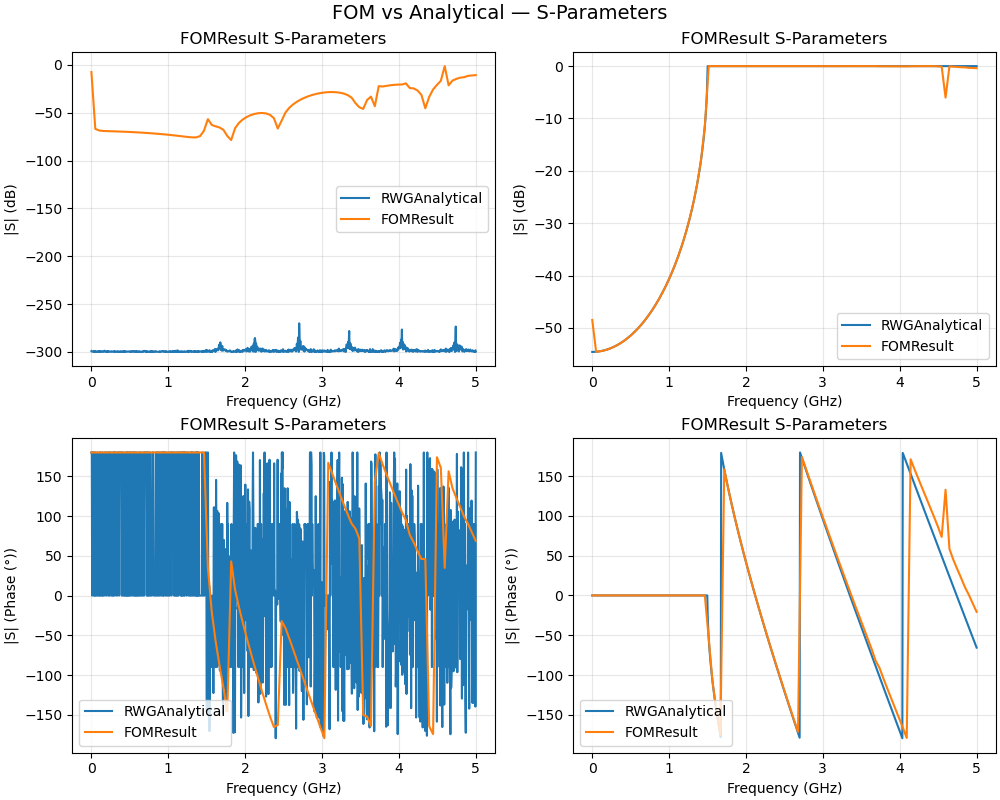

In [11]:
from analytical.rectangular_waveguide import RWGAnalytical

# Create analytical model with same dimensions and frequency range
analytical = RWGAnalytical(
    a=0.1, L=0.2,
    freq_range=(fom_config['fmin'], fom_config['fmax'])
)

# Plot comparison: FOM vs Analytical
which = [['1(1)1(1)'], ['1(1)2(1)']]

fig, axs = plt.subplot_mosaic(
    [[1, 2], [3, 4]], figsize=(10, 8), layout='constrained'
)

for idx, wh in enumerate(which):
    # Magnitude
    analytical.plot_s(wh, ax=axs[idx + 1])
    proj.fds.fom.plot_s(wh, ax=axs[idx + 1])
    # Phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx + 3])
    proj.fds.fom.plot_s(wh, plot_type='phase', ax=axs[idx + 3])

fig.suptitle('FOM vs Analytical — S-Parameters', fontsize=14)

## Summary

In this tutorial we:
1. Created an `EMProject` to manage the simulation
2. Defined a rectangular waveguide geometry
3. Configured and ran the Frequency Domain Solver via a config dictionary
4. Plotted S-parameter magnitude and phase
5. Validated results against the closed-form analytical solution

**Next:** Try [Pathway 2: Global Assembly](pathway2_global_assembly.ipynb) to analyse multi-component structures.